In [32]:
import pandas as pd

In [33]:
# B1. Khám phá dữ liệu
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
print(df.shape)

(891, 12)


In [35]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [36]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [37]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Text(0, 0.5, 'Frequency')

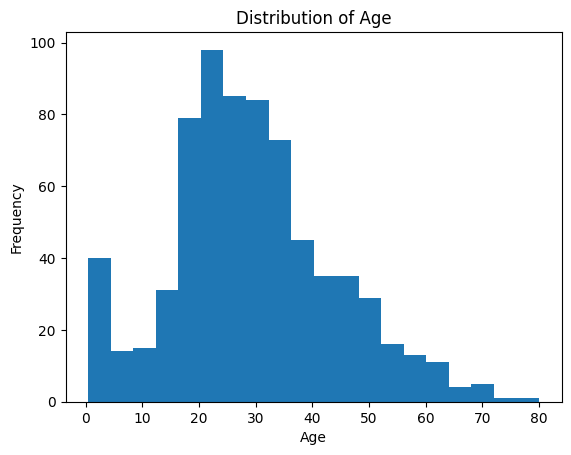

In [38]:
# Vẽ phân phối cho cột 'Age'
import matplotlib.pyplot as plt
plt.hist(df['Age'].dropna(), bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

In [39]:
# Xử lý dữ liệu thiếu
# Điền giá trị trung bình cho cột 'Age'
df['Age'].fillna(df['Age'].mean(), inplace=True)
df.describe()

/var/folders/10/3dssf0p51vzgb7zfm9xl0vrm0000gn/T/ipykernel_13866/678204162.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
# Điền mode cho cột 'Embarked'
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# Xóa cột 'Cabin' vì có quá nhiều giá trị thiếu
df.drop(columns=['Cabin'], inplace=True)
df.shape

/var/folders/10/3dssf0p51vzgb7zfm9xl0vrm0000gn/T/ipykernel_13866/1921323978.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


(891, 11)

In [41]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

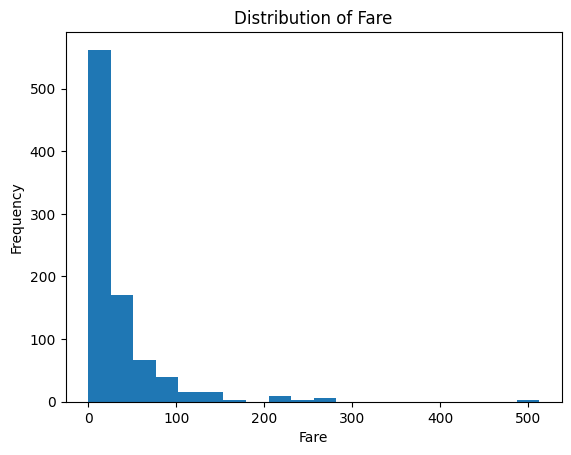

In [42]:
# Vẽ phân phối của vé
plt.hist(df['Fare'], bins=20)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency') 
plt.show()

In [43]:
from scipy import stats

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f'Lower bound: {lower}, Upper bound: {upper}')
outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(outliers.shape)

Lower bound: -26.724, Upper bound: 65.6344
(116, 11)


In [44]:
# Xóa ngoại lệ
df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]
print(df.shape)

(775, 11)


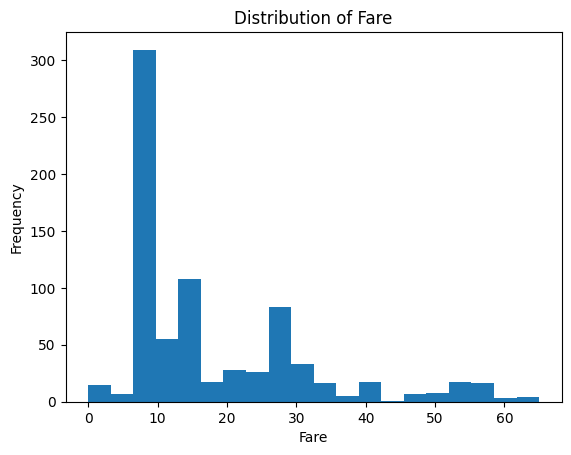

In [45]:
plt.hist(df['Fare'], bins=20)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency') 
plt.show()

In [46]:
df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
df['Title'].unique()

array(['Mr', 'Miss', 'Mrs', 'Master', 'Don', 'Rev', 'Dr', 'Ms', 'Major',
       'Lady', 'Sir', 'Col', 'Mlle', 'Jonkheer'], dtype=object)

In [47]:
df['Title'].value_counts()

Title
Mr          478
Miss        143
Mrs          97
Master       36
Rev           6
Dr            5
Major         2
Col           2
Don           1
Ms            1
Lady          1
Sir           1
Mlle          1
Jonkheer      1
Name: count, dtype: int64

In [48]:
df['Title'] = df['Title'].replace(['Ms', 'Mlle'], 'Miss')
df['Title'] = df['Title'].replace(['Master', 'Rev', 'Dr', 'Major', 'Col', 'Don', 'Lady', 'Sir', 'Jonkheer'], 'Other')
df['Title'].value_counts()

Title
Mr       478
Miss     145
Mrs       97
Other     55
Name: count, dtype: int64

In [49]:
print(df.groupby('Title')['Survived'].mean())

Title
Miss     0.648276
Mr       0.148536
Mrs      0.742268
Other    0.472727
Name: Survived, dtype: float64


In [50]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(df.groupby('FamilySize')['Survived'].mean())

FamilySize
1    0.270378
2    0.487603
3    0.575000
4    0.727273
5    0.076923
6    0.055556
7    0.333333
8    0.000000
Name: Survived, dtype: float64


In [51]:
df['Alone'] = df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)
df['Alone'].value_counts()

Alone
1    503
0    272
Name: count, dtype: int64

In [52]:
bins = [0, 12, 18, 35, 60, 80]
labels = ['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df.groupby('AgeGroup')['Survived'].mean())

AgeGroup
Child          0.569231
Teenager       0.366667
Adult          0.323591
Middle-aged    0.300654
Senior         0.166667
Name: Survived, dtype: float64


/var/folders/10/3dssf0p51vzgb7zfm9xl0vrm0000gn/T/ipykernel_13866/1277883661.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Survived'].mean())


In [53]:
df['FareGroup'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
print(df.groupby('FareGroup')['Survived'].mean())

FareGroup
Low          0.197309
Medium       0.302439
High         0.422619
Very High    0.480447
Name: Survived, dtype: float64


/var/folders/10/3dssf0p51vzgb7zfm9xl0vrm0000gn/T/ipykernel_13866/381049234.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('FareGroup')['Survived'].mean())


In [54]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [55]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
print(df['Sex'].value_counts())

Sex
1    531
0    244
Name: count, dtype: int64


In [58]:
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])
df['FareGroup_Encoded'] = oe.fit_transform(df[['FareGroup']])
print(df[['FareGroup', 'FareGroup_Encoded']].value_counts())

FareGroup  FareGroup_Encoded
Low        0.0                  223
Medium     1.0                  205
Very High  3.0                  179
High       2.0                  168
Name: count, dtype: int64


In [60]:
oh = OneHotEncoder(sparse_output=False)
embarked_encoded = oh.fit_transform(df[['Embarked']])
print(oh.get_feature_names_out(['Embarked']))

['Embarked_C' 'Embarked_Q' 'Embarked_S']


In [62]:
print(embarked_encoded.shape)

(775, 3)


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   PassengerId        775 non-null    int64   
 1   Survived           775 non-null    int64   
 2   Pclass             775 non-null    int64   
 3   Name               775 non-null    object  
 4   Sex                775 non-null    int64   
 5   Age                775 non-null    float64 
 6   SibSp              775 non-null    int64   
 7   Parch              775 non-null    int64   
 8   Ticket             775 non-null    object  
 9   Fare               775 non-null    float64 
 10  Embarked           775 non-null    object  
 11  Title              775 non-null    object  
 12  FamilySize         775 non-null    int64   
 13  Alone              775 non-null    int64   
 14  AgeGroup           775 non-null    category
 15  FareGroup          775 non-null    category
 16  FareGroup_Enc

In [63]:
# Ghép embarked_encoded vào df
df = pd.concat([df, pd.DataFrame(embarked_encoded, columns=oh.get_feature_names_out(['Embarked']))], axis=1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,Alone,AgeGroup,FareGroup,FareGroup_Encoded,Embarked_C,Embarked_Q,Embarked_S
0,1.0,0.0,3.0,"Braund, Mr. Owen Harris",1.0,22.000000,1.0,0.0,A/5 21171,7.2500,S,Mr,2.0,0.0,Adult,Low,0.0,0.0,0.0,1.0
2,3.0,1.0,3.0,"Heikkinen, Miss. Laina",0.0,26.000000,0.0,0.0,STON/O2. 3101282,7.9250,S,Miss,1.0,1.0,Adult,Medium,1.0,0.0,0.0,1.0
3,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,35.000000,1.0,0.0,113803,53.1000,S,Mrs,2.0,0.0,Adult,Very High,3.0,0.0,0.0,1.0
4,5.0,0.0,3.0,"Allen, Mr. William Henry",1.0,35.000000,0.0,0.0,373450,8.0500,S,Mr,1.0,1.0,Adult,Medium,1.0,0.0,1.0,0.0
5,6.0,0.0,3.0,"Moran, Mr. James",1.0,29.699118,0.0,0.0,330877,8.4583,Q,Mr,1.0,1.0,Adult,Medium,1.0,0.0,0.0,1.0


In [68]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

df_copy = df[['Age', 'Fare', 'SibSp', 'Parch']].copy()

scalers = {
    'StandardScaler': StandardScaler().fit_transform(df_copy),
    'MinMaxScaler': MinMaxScaler().fit_transform(df_copy),
    'RobustScaler': RobustScaler().fit_transform(df_copy),
    'Original': df_copy.values
}

# Mean sau chuẩn hóa
for name, scaled in scalers.items():
    print(name)
    print(f'{'Col':20}{'Mean':20}{'Std':20}{'Min':20}{'Max':20}')
    mean_ = pd.DataFrame(scaled, columns=df_copy.columns).mean()
    std_ = pd.DataFrame(scaled, columns=df_copy.columns).std()
    min_ = pd.DataFrame(scaled, columns=df_copy.columns).min()
    max_ = pd.DataFrame(scaled, columns=df_copy.columns).max()
    for col in df_copy.columns:
        print(f'{col:20}{mean_[col]:<20.4f}{std_[col]:<20.4f}{min_[col]:<20.4f}{max_[col]:<20.4f}')

StandardScaler
Col                 Mean                Std                 Min                 Max                 
Age                 0.0000              1.0006              -2.2459             3.9851              
Fare                0.0000              1.0006              -1.3134             3.4768              
SibSp               0.0000              1.0006              -0.4864             5.0737              
Parch               0.0000              1.0006              -0.4337             7.2056              
MinMaxScaler
Col                 Mean                Std                 Min                 Max                 
Age                 0.3604              0.1606              0.0000              1.0000              
Fare                0.2742              0.2089              0.0000              1.0000              
SibSp               0.0875              0.1800              0.0000              1.0000              
Parch               0.0568              0.1310              0.0

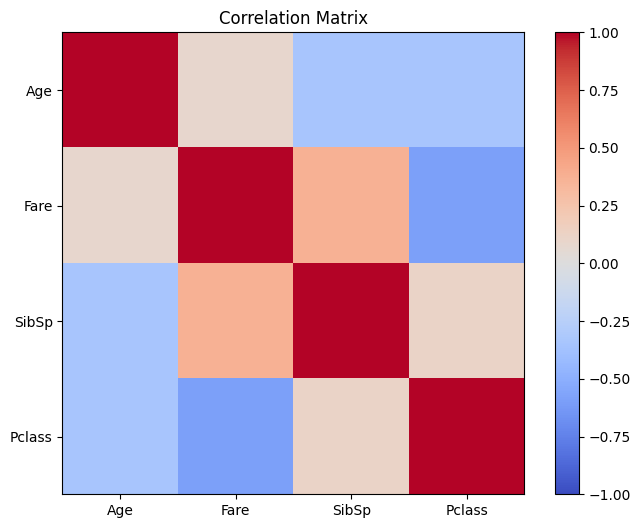

In [ ]:
num_features = ['Age', 'Fare', 'SibSp', 'Pclass']
corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_features)))
ax.set_yticks(range(len(num_features)))
ax.set_xticklabels(num_features)
ax.set_yticklabels(num_features)
fig.colorbar(cax)
plt.title('Correlation Matrix')
plt.show()

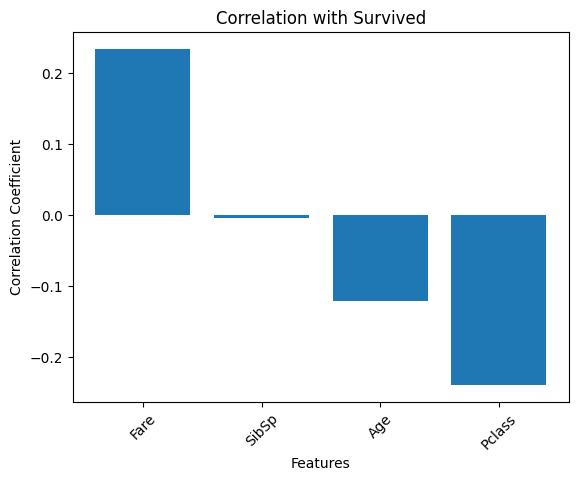

In [72]:
features = ['Age', 'Fare', 'SibSp', 'Pclass']
corr_survived = df[features + ['Survived']].corr()['Survived'].drop('Survived').sort_values(ascending=False)

plt.bar(corr_survived.index, corr_survived.values)
plt.title('Correlation with Survived')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.show()